# Data Preparation

## Current Problem

Our data has an imbalance of 94:6 (no claim : claim)

We want to have a similar amount of labels or classes that would help us identify claim and no claim. Having the majority as claim would not give enough data to our model to how a "no claim" policy holder would look like. 

Hence, we employ data-level techniques such as:

- SMOTE (Synthetic Minority Oversampling Technique)
    - Creates synthetic samples by interpolating between existing minority samples and their neighbors

- Random Undersampling

    - Removes majority class samples randomly

- Tomek Links
    - Remove pairs of examples from opposite classes that are nearest neighbors
    



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, precision_recall_curve, average_precision_score,
    roc_curve, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
import kagglehub
import os


In [2]:
path = kagglehub.dataset_download("litvinenko630/insurance-claims")

# List all files in the downloaded directory
files = os.listdir(path)
file_path = os.path.join(path, "Insurance claims data.csv")
df = pd.read_csv(file_path)



In [3]:
from helpers.preprocess import *

df_processed = preprocess_data(df)
df_processed, _ = train_test_split(
    df_processed, 
    train_size=0.10,      # Keep 10% of the data
    stratify=df_processed['claim_status'], 
    random_state=42
)

print(f"Processed shape: {df_processed.shape}")
print(f"\nFeature types after processing:")
print(df_processed.dtypes.value_counts())

Processed shape: (5859, 58677)

Feature types after processing:
bool       58660
int64         10
float64        7
Name: count, dtype: int64


In [4]:
# Separate features and target
X = df_processed.drop('claim_status', axis=1)
y = df_processed['claim_status']

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts())

Training set: 4687 samples
Test set: 1172 samples

Training class distribution:
claim_status
0    4387
1     300
Name: count, dtype: int64


## SMOTE

1. For each minority sample, find its k nearest neighbors (default k=5)
2. Randomly select one of those neighbors
3. Create a new synthetic sample along the line connecting them

Formula: `new_sample = original + random(0,1) × (neighbor - original)` 

This creates realistic variations that help the model generalize better.

### Also has some Variants
#### BorderlineSMOTE
Only generates synthetic samples for minority instances that are **near the decision boundary** (close to majority samples). This focuses on the hard-to-classify cases.

#### ADASYN (Adaptive Synthetic Sampling)
Generates **more synthetic samples** for minority instances that are harder to classify (surrounded by majority samples). It's adaptive to the local density.

Our goal here is to identify which sampling technique to use.

In [5]:
# Scale features to standardize them
# mean = 0, sigma = 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
from helpers.compare_resampling import (
    compare_resampling_techniques,
    display_comparison,
    plot_comparison
)

Training: Baseline (No Resampling)...
 Done - F1: 0.0000, AUC-PR: 0.0789
Training: SMOTE...
 Done - F1: 0.0000, AUC-PR: 0.0795
Training: BorderlineSMOTE...
 Done - F1: 0.0000, AUC-PR: 0.0955
Training: ADASYN...
 Done - F1: 0.0000, AUC-PR: 0.0980
Training: SMOTE + Tomek...
 Done - F1: 0.0000, AUC-PR: 0.0795

RESAMPLING TECHNIQUES COMPARISON
               Technique Train Samples Minority Samples Precision Recall F1 Score AUC-ROC AUC-PR
Baseline (No Resampling)         4,687              300    0.0000 0.0000   0.0000  0.5663 0.0789
                   SMOTE         8,774            4,387    0.0000 0.0000   0.0000  0.5536 0.0795
         BorderlineSMOTE         8,774            4,387    0.0000 0.0000   0.0000  0.5881 0.0955
                  ADASYN         8,812            4,425    0.0000 0.0000   0.0000  0.5965 0.0980
           SMOTE + Tomek         8,774            4,387    0.0000 0.0000   0.0000  0.5536 0.0795

Best by F1 Score: Baseline (No Resampling) (F1: 0.0000)
Best by AUC-PR: ADA

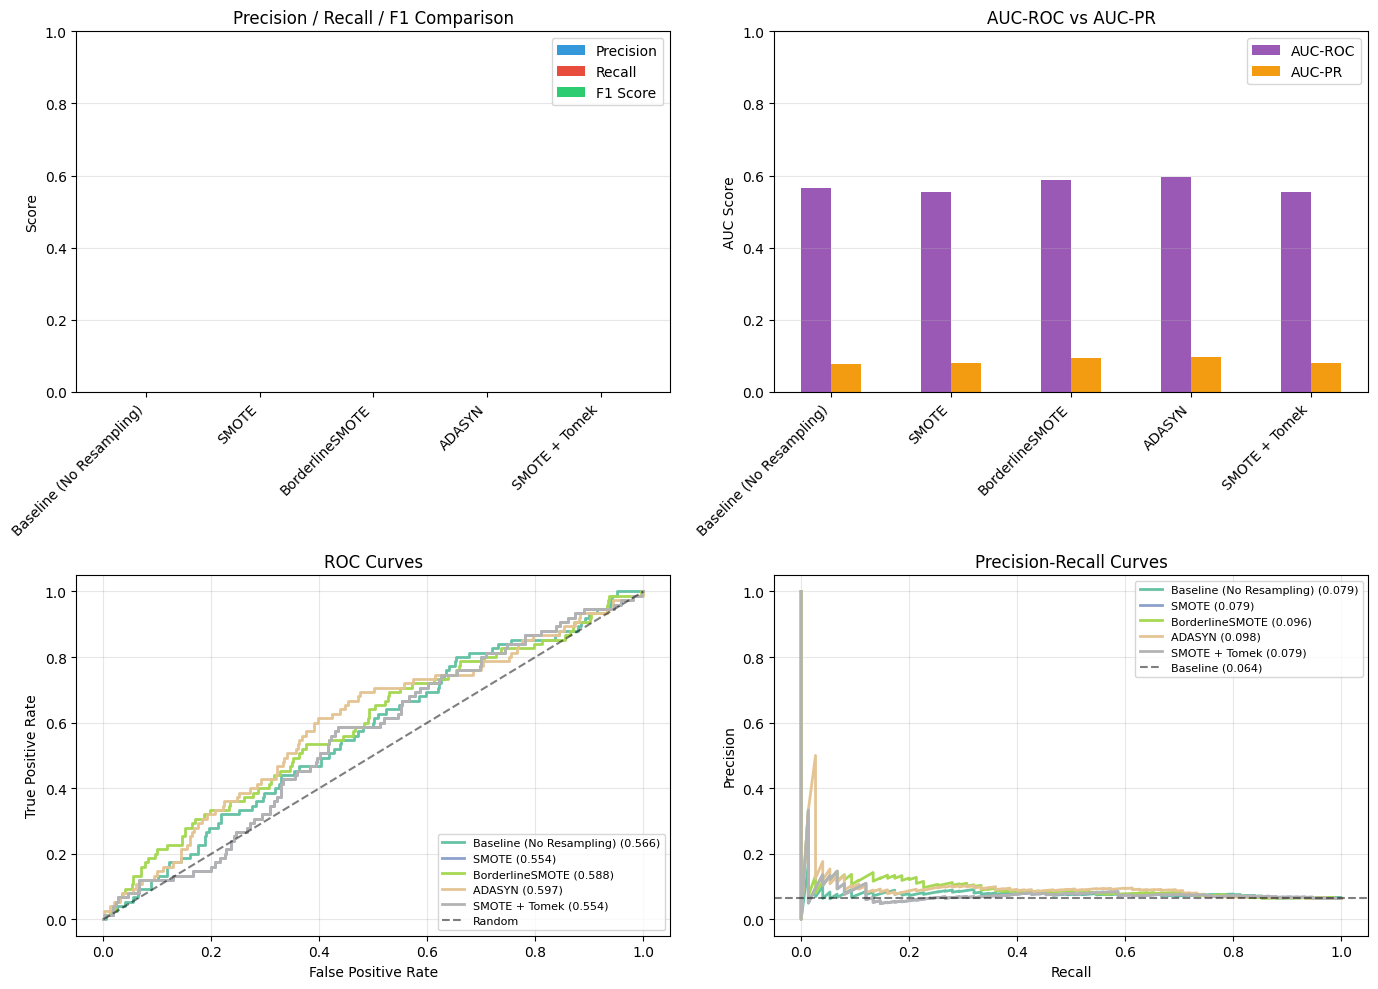


 Plot saved as 'resampling_comparison.png'


In [7]:
results_df, detailed_results = compare_resampling_techniques(
    X_train_scaled, y_train,
    X_test_scaled, y_test
)
 
# Display results table
display_comparison(results_df)
 
# Create visualizations
plot_comparison(results_df, detailed_results, y_test)
